# **☄️ NEO Hazard Prediction — ANN (Artificial Neural Network)**

# **Step 1: Install & Import Libraries**

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # suppress verbose TF logs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('✅ Libraries imported!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   Keras version      : {keras.__version__}')

✅ Libraries imported!
   TensorFlow version : 2.20.0
   Keras version      : 3.13.2


# **Step 2: Load Data & Feature Engineering**

In [2]:
df = pd.read_csv('sprint1.csv')

In [3]:
df

,Unnamed: 0,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0.0
1,1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1.0
2,2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0.0
3,3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0.0
4,4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1.0
...,...,...,...,...,...,...,...
14270,14271,0.103886,0.232295,36605.027708,3.859821e+07,22.04,0.0
14271,14272,0.011235,0.025121,44886.191505,2.600571e+07,26.87,0.0
14272,14273,0.329622,0.737056,46132.672799,2.164147e+07,16.95,0.0
14273,14274,0.278327,0.622358,77517.287080,5.059082e+07,19.90,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14275 entries, 0 to 14274
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          14275 non-null  int64  
 1   est_diameter_min    14275 non-null  float64
 2   est_diameter_max    14275 non-null  float64
 3   relative_velocity   14275 non-null  float64
 4   miss_distance       14275 non-null  float64
 5   absolute_magnitude  14274 non-null  float64
 6   hazardous           14274 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 780.8 KB


In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0.0
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1.0
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0.0
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0.0
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1.0
...,...,...,...,...,...,...
14270,0.103886,0.232295,36605.027708,3.859821e+07,22.04,0.0
14271,0.011235,0.025121,44886.191505,2.600571e+07,26.87,0.0
14272,0.329622,0.737056,46132.672799,2.164147e+07,16.95,0.0
14273,0.278327,0.622358,77517.287080,5.059082e+07,19.90,0.0


In [7]:
df.shape

(14275, 6)

In [8]:
df.isnull().sum()

,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
absolute_magnitude,1
hazardous,1


In [9]:
df['absolute_magnitude'].mean()

np.float64(23.025301737424687)

In [10]:
df['absolute_magnitude'].fillna(df['absolute_magnitude'].mean(), inplace=True)

In [11]:
df['hazardous'].mode()

,hazardous
0,0.0


In [20]:
df['hazardous'].fillna(0, inplace=True)

In [21]:
df.isnull().sum()

,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
absolute_magnitude,0
hazardous,0
Avg_diameter,0
Diameter_range,0
Velocity_distance_ratio,0
log_velocity,0


In [22]:
df["hazardous"].value_counts()

,count
hazardous,
0.0,12475
1.0,1800


In [23]:
##  Feature Engineering

df['Avg_diameter']            = (df['est_diameter_min'] + df['est_diameter_max']) / 2
df['Diameter_range']          = df['est_diameter_max'] - df['est_diameter_min']
df['Velocity_distance_ratio'] = df['relative_velocity'] / df['miss_distance']
df['log_velocity']            = np.log1p(df['relative_velocity'])
df['log_miss_distance']       = np.log1p(df['miss_distance'])

In [24]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,Avg_diameter,Diameter_range,Velocity_distance_ratio,log_velocity,log_miss_distance
0,0.329622,0.737056,13569.249224,5.483974e+07,16.730000,0.0,0.533339,0.407435,0.000247,9.515635,17.819926
1,0.265800,0.594347,73588.726663,6.143813e+07,20.000000,1.0,0.430073,0.328547,0.001198,11.206261,17.933541
2,0.329622,0.737056,114258.692129,4.979872e+07,17.830000,0.0,0.533339,0.407435,0.002294,11.646229,17.723500
3,0.096506,0.215794,24764.303138,2.543497e+07,22.200000,0.0,0.156150,0.119288,0.000974,10.117199,17.051636
4,0.255009,0.570217,42737.733765,4.627557e+07,20.090000,1.0,0.412613,0.315208,0.000924,10.662861,17.650125
...,...,...,...,...,...,...,...,...,...,...,...
14270,0.103886,0.232295,36605.027708,3.859821e+07,22.040000,0.0,0.168090,0.128410,0.000948,10.507968,17.468716
14271,0.011235,0.025121,44886.191505,2.600571e+07,26.870000,0.0,0.018178,0.013887,0.001726,10.711908,17.073827
14272,0.329622,0.737056,46132.672799,2.164147e+07,16.950000,0.0,0.533339,0.407435,0.002132,10.739298,16.890122
14273,0.278327,0.622358,77517.287080,5.059082e+07,19.900000,0.0,0.450342,0.344031,0.001532,11.258269,17.739281


# **Step 3: Train / Validation / Test Split & Scaling**

In [25]:
X = df.drop('hazardous', axis=1)
y = df['hazardous']

In [26]:
X.shape, y.shape

((14275, 10), (14275,))

In [27]:
# ── Train / Test split (80 / 20) with stratification ────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [28]:
X_train_full.shape, X_test.shape, y_train_full.shape, y_test.shape

((11420, 10), (2855, 10), (11420,), (2855,))

In [29]:
# ── Carve out a validation set from training (15% of train) ──────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, random_state=42, stratify=y_train_full
)

In [30]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((9707, 10), (1713, 10), (9707,), (1713,))

In [31]:
# ── StandardScaler — fit ONLY on training data ───────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


In [32]:
# Input dimensions after scaling
X_train_s.shape[1]

10

In [33]:
# Class Weights to handle 9:1 imbalance
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

In [34]:
print(cw[0])
print(cw[1])

0.5721442885771543
3.9652777777777777


# **Step 4: ANN Architecture**

In [35]:
def build_ann(input_dim,
              unit_1 = 128,
              unit_2 = 64,
              unit_3 = 32,
              dropout_rate = 0.2,
              learning_rate = 0.001,
              l2_reg = 0.001):
  model = keras.Sequential([
        # Input
        layers.Input(shape=(input_dim,)),

        # Hidden Layer 1
        layers.Dense(unit_1, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg),
                     name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        # Hidden Layer 2
        layers.Dense(unit_2, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg),
                     name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        # Hidden Layer 3
        layers.Dense(unit_3, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg),
                     name='dense_3'),
        layers.Dropout(dropout_rate / 2, name='dropout_3'),

        # Output — Sigmoid for binary probability
        layers.Dense(1, activation='sigmoid', name='output')
    ])
  model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
  return model
model = build_ann(input_dim=X_train_s.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 384 (1.50 KB)

# **Step 5: Training Callbacks**

In [36]:
cb_list = [

    # 1. Early Stopping — stop when val AUC stops improving
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,  # revert to best epoch automatically
        mode='max',
        verbose=1
    ),

    # 2. ReduceLROnPlateau — halve LR when val loss plateaus
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # 3. ModelCheckpoint — save best model weights
    callbacks.ModelCheckpoint(
        filepath='best_ann_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=0
    )
]

# **Step 6: Train Baseline ANN**

In [37]:
history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.6952 - auc: 0.7857 - loss: 0.7102 - precision: 0.2591 - recall: 0.7623 - val_accuracy: 0.7204 - val_auc: 0.8499 - val_loss: 0.6878 - val_precision: 0.3040 - val_recall: 0.9444 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7169 - auc: 0.8504 - loss: 0.5794 - precision: 0.2973 - recall: 0.9134 - val_accuracy: 0.8138 - val_auc: 0.8641 - val_loss: 0.6008 - val_precision: 0.3549 - val_recall: 0.5833 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7305 - auc: 0.8654 - loss: 0.5420 - precision: 0.3111 - recall: 0.9363 - val_accuracy: 0.7834 - val_auc: 0.8587 - val_loss: 0.5539 - val_precision: 0.3289 - val_recall: 0.6898 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7284 - auc: 0.8649 - loss: 0.5303 - precision: 0.3101 - recall: 0.9420 - val_accuracy: 0.7717 - val_auc: 0.8609 - val_loss: 0.5181 - val

In [38]:
# Best epoch
np.argmax(history.history["val_auc"]) + 1

np.int64(56)

In [39]:
# Best val AUC
max(history.history["val_auc"])

0.8783307671546936

# **Step 7: Training Curves**

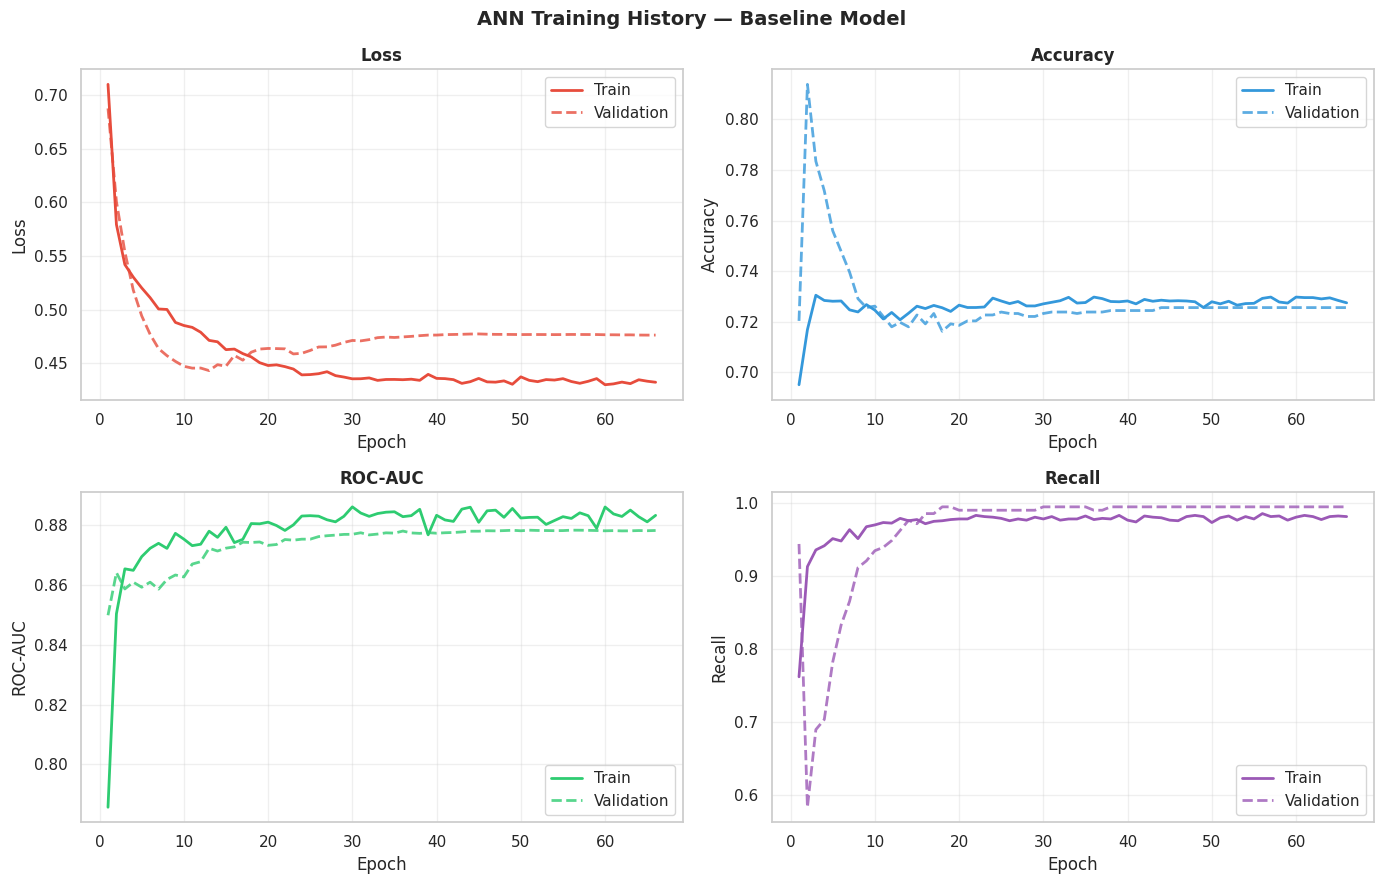

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('ANN Training History — Baseline Model', fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('loss',     'Loss',     '#e74c3c'),
    ('accuracy', 'Accuracy', '#3498db'),
    ('auc',      'ROC-AUC',  '#2ecc71'),
    ('recall',   'Recall',   '#9b59b6'),
]

for ax, (key, title, color) in zip(axes.flatten(), metrics_to_plot):
    train_vals = history.history[key]
    val_vals   = history.history[f'val_{key}']
    epochs     = range(1, len(train_vals) + 1)

    ax.plot(epochs, train_vals, color=color,     linewidth=2, label='Train')
    ax.plot(epochs, val_vals,   color=color, linestyle='--', linewidth=2, label='Validation', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Step 8: Hyperparameter Tuning (Manual Grid Search)**

In [41]:
param_grid = [
    {'units_1': 256, 'units_2': 128, 'units_3': 64,  'dropout_rate': 0.3, 'lr': 0.001, 'l2': 0.001},
    {'units_1': 128, 'units_2': 64,  'units_3': 32,  'dropout_rate': 0.3, 'lr': 0.001, 'l2': 0.001},
    {'units_1': 128, 'units_2': 64,  'units_3': 32,  'dropout_rate': 0.4, 'lr': 0.001, 'l2': 0.0001},
    {'units_1': 64,  'units_2': 32,  'units_3': 16,  'dropout_rate': 0.2, 'lr': 0.001, 'l2': 0.001},
    {'units_1': 256, 'units_2': 128, 'units_3': 64,  'dropout_rate': 0.4, 'lr': 0.0005, 'l2': 0.001},
]

In [42]:
len(param_grid)

5

In [43]:
tuning_results = []
best_val_auc   = 0
best_config    = None
best_model_hp  = None

cb_tune = [
    callbacks.EarlyStopping(monitor='val_auc', patience=8,
                            restore_best_weights=True, mode='max', verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=0)
]

for i, params in enumerate(param_grid):
    print(f'\n[{i+1}/{len(param_grid)}] Config: {params}')

    tf.random.set_seed(42)
    m = build_ann(
        input_dim    = X_train_s.shape[1],
        unit_1      = params['units_1'],
        unit_2      = params['units_2'],
        unit_3      = params['units_3'],
        dropout_rate = params['dropout_rate'],
        learning_rate= params['lr'],
        l2_reg       = params['l2']
    )

    h = m.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=50,
        batch_size=512,
        class_weight=class_weight_dict,
        callbacks=cb_tune,
        verbose=0
    )

    best_epoch_val_auc = max(h.history['val_auc'])
    epochs_ran = len(h.history['val_auc'])

    tuning_results.append({
        **params,
        'val_auc'  : round(best_epoch_val_auc, 4),
        'epochs'   : epochs_ran
    })

    print(f'   → val_auc: {best_epoch_val_auc:.4f} | epochs: {epochs_ran}')

    if best_epoch_val_auc > best_val_auc:
        best_val_auc  = best_epoch_val_auc
        best_config   = params
        best_model_hp = m

print(f'\n✅ Best val_auc: {best_val_auc:.4f}')
print(f'   Best config : {best_config}')


[1/5] Config: {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_rate': 0.3, 'lr': 0.001, 'l2': 0.001}
   → val_auc: 0.8757 | epochs: 20

[2/5] Config: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout_rate': 0.3, 'lr': 0.001, 'l2': 0.001}
   → val_auc: 0.8647 | epochs: 8

[3/5] Config: {'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout_rate': 0.4, 'lr': 0.001, 'l2': 0.0001}
   → val_auc: 0.8613 | epochs: 8

[4/5] Config: {'units_1': 64, 'units_2': 32, 'units_3': 16, 'dropout_rate': 0.2, 'lr': 0.001, 'l2': 0.001}
   → val_auc: 0.8650 | epochs: 8

[5/5] Config: {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_rate': 0.4, 'lr': 0.0005, 'l2': 0.001}
   → val_auc: 0.8616 | epochs: 8

✅ Best val_auc: 0.8757
   Best config : {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_rate': 0.3, 'lr': 0.001, 'l2': 0.001}


In [44]:
tuning_results

[{'units_1': 256,
  'units_2': 128,
  'units_3': 64,
  'dropout_rate': 0.3,
  'lr': 0.001,
  'l2': 0.001,
  'val_auc': 0.8757,
  'epochs': 20},
 {'units_1': 128,
  'units_2': 64,
  'units_3': 32,
  'dropout_rate': 0.3,
  'lr': 0.001,
  'l2': 0.001,
  'val_auc': 0.8647,
  'epochs': 8},
 {'units_1': 128,
  'units_2': 64,
  'units_3': 32,
  'dropout_rate': 0.4,
  'lr': 0.001,
  'l2': 0.0001,
  'val_auc': 0.8613,
  'epochs': 8},
 {'units_1': 64,
  'units_2': 32,
  'units_3': 16,
  'dropout_rate': 0.2,
  'lr': 0.001,
  'l2': 0.001,
  'val_auc': 0.865,
  'epochs': 8},
 {'units_1': 256,
  'units_2': 128,
  'units_3': 64,
  'dropout_rate': 0.4,
  'lr': 0.0005,
  'l2': 0.001,
  'val_auc': 0.8616,
  'epochs': 8}]

In [45]:
best_val_auc

0.8757237195968628

In [46]:
best_config

{'units_1': 256,
 'units_2': 128,
 'units_3': 64,
 'dropout_rate': 0.3,
 'lr': 0.001,
 'l2': 0.001}

In [47]:
best_model_hp

<Sequential name=sequential_1, built=True>

In [48]:
#  Hyperparameter Tuning Results Table
results_df = pd.DataFrame(tuning_results).sort_values('val_auc', ascending=False)

In [49]:
results_df

,units_1,units_2,units_3,dropout_rate,lr,l2,val_auc,epochs
0,256,128,64,0.3,0.0010,0.0010,0.8757,20
3,64,32,16,0.2,0.0010,0.0010,0.8650,8
1,128,64,32,0.3,0.0010,0.0010,0.8647,8
4,256,128,64,0.4,0.0005,0.0010,0.8616,8
2,128,64,32,0.4,0.0010,0.0001,0.8613,8


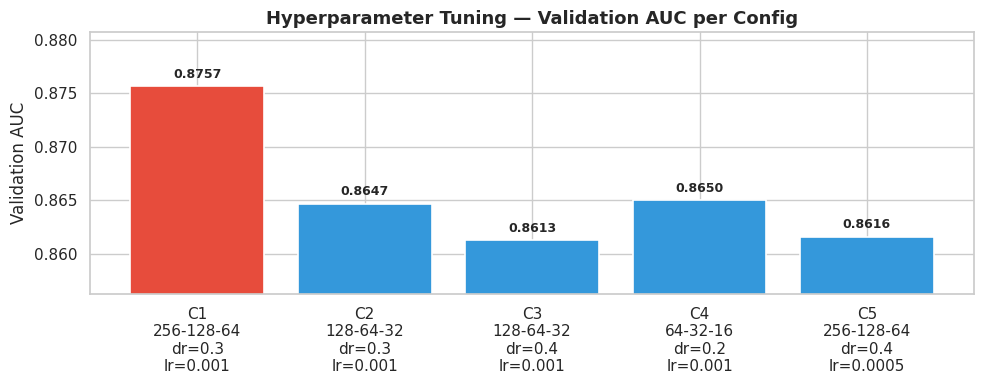

In [50]:
fig, ax = plt.subplots(figsize=(10, 4))

configs = [f"C{i+1}\n{p['units_1']}-{p['units_2']}-{p['units_3']}\ndr={p['dropout_rate']}\nlr={p['lr']}"
           for i, p in enumerate(param_grid)]
aucs    = [r['val_auc'] for r in tuning_results]

bars = ax.bar(configs, aucs, color=['#e74c3c' if a == max(aucs) else '#3498db' for a in aucs],
              edgecolor='white', linewidth=1.2)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Hyperparameter Tuning — Validation AUC per Config', fontsize=13, fontweight='bold')
ax.set_ylim(min(aucs) - 0.005, max(aucs) + 0.005)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0005,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [51]:
# Best configuration
max(aucs)

0.8757

# **Step 9: Train Final ANN (Best Hyperparameters)**

In [52]:
for k, v in best_config.items():
    print(f'   {k}: {v}')
print()

tf.random.set_seed(42)
final_model = build_ann(
    input_dim    = X_train_s.shape[1],
    unit_1      = best_config['units_1'],
    unit_2      = best_config['units_2'],
    unit_3      = best_config['units_3'],
    dropout_rate = best_config['dropout_rate'],
    learning_rate= best_config['lr'],
    l2_reg       = best_config['l2']
)

cb_final = [
    callbacks.EarlyStopping(monitor='val_auc', patience=10,
                            restore_best_weights=True, mode='max', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_ann_final.keras', monitor='val_auc',
                               save_best_only=True, mode='max', verbose=0)
]

history_final = final_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=cb_final,
    verbose=1
)

print('\n Final model trained!')
print(f'   Best val AUC : {max(history_final.history["val_auc"]):.4f}')

   units_1: 256
   units_2: 128
   units_3: 64
   dropout_rate: 0.3
   lr: 0.001
   l2: 0.001

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7204 - auc: 0.8354 - loss: 0.7590 - precision: 0.2920 - recall: 0.8546 - val_accuracy: 0.8214 - val_auc: 0.8711 - val_loss: 0.7618 - val_precision: 0.3628 - val_recall: 0.5509 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7326 - auc: 0.8575 - loss: 0.6797 - precision: 0.3094 - recall: 0.9101 - val_accuracy: 0.7408 - val_auc: 0.8685 - val_loss: 0.7049 - val_precision: 0.3137 - val_recall: 0.8889 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7261 - auc: 0.8638 - loss: 0.6513 - precision: 0.3073 - recall: 0.9346 - val_accuracy: 0.7309 - val_auc: 0.8599 - val_loss: 0.6769 - val_precision: 0.3083 - val_recall: 0.9120 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7263 - auc: 0.8734 - loss: 0.6305 - preci

# **Step 10: Threshold Tuning (Optimize for F1 on Validation)**

 Threshold tuning complete!
   Best threshold : 0.47
   Best val F1    : 0.4764


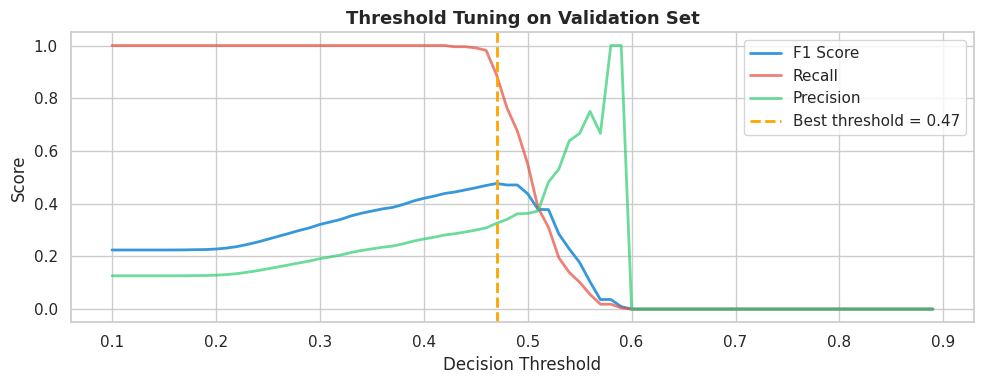

In [53]:
val_probs = final_model.predict(X_val_s, verbose=0).flatten()

thresholds  = np.arange(0.10, 0.90, 0.01)
f1_scores   = []
recall_scores = []
prec_scores = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    recall_scores.append(recall_score(y_val, preds, zero_division=0))
    prec_scores.append(precision_score(y_val, preds, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f' Threshold tuning complete!')
print(f'   Best threshold : {best_threshold:.2f}')
print(f'   Best val F1    : {best_f1:.4f}')

# Plot
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,    label='F1 Score',  color='#3498db', linewidth=2)
plt.plot(thresholds, recall_scores,label='Recall',    color='#e74c3c', linewidth=2, alpha=0.7)
plt.plot(thresholds, prec_scores,  label='Precision', color='#2ecc71', linewidth=2, alpha=0.7)
plt.axvline(best_threshold, color='orange', linestyle='--', linewidth=2,
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Threshold Tuning on Validation Set', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# **Step 11: Final Evaluation on Test Set**

In [54]:
# Predict probabilities on test set
y_prob_test  = final_model.predict(X_test_s, verbose=0).flatten()
y_pred_test  = (y_prob_test >= best_threshold).astype(int)
y_pred_050   = (y_prob_test >= 0.50).astype(int)   # default threshold for comparison


In [55]:
y_pred_test.shape

(2855,)

In [56]:
y_prob_test.shape

(2855,)

In [57]:
y_pred_050.shape

(2855,)

In [58]:
# Metrics at best threshold
acc   = accuracy_score(y_test, y_pred_test)
prec  = precision_score(y_test, y_pred_test)
rec   = recall_score(y_test, y_pred_test)
f1    = f1_score(y_test, y_pred_test)
auc   = roc_auc_score(y_test, y_prob_test)


In [59]:
acc

0.759369527145359

In [60]:
prec

0.3305699481865285

In [61]:
rec

0.8861111111111111

In [62]:
f1

0.48150943396226414

In [63]:
auc

np.float64(0.872187708750835)

In [64]:
best_threshold

np.float64(0.46999999999999986)

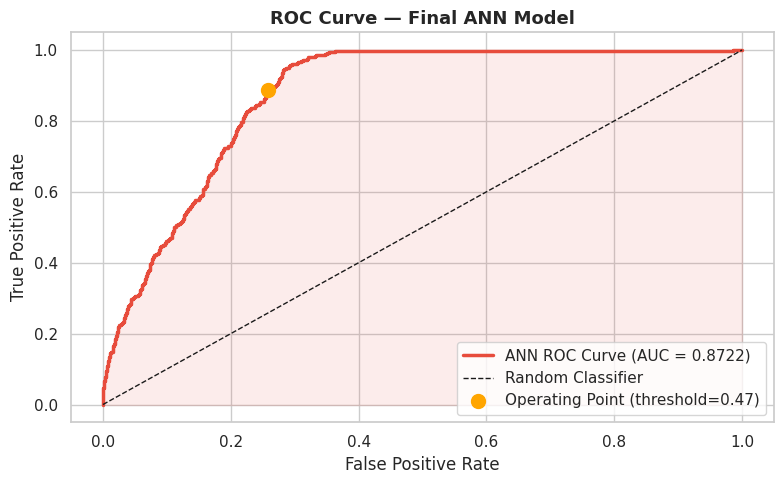

In [65]:
#  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5,
         label=f'ANN ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.scatter([fpr[np.argmin(np.abs(tpr - rec))]], [rec],
            color='orange', s=100, zorder=5,
            label=f'Operating Point (threshold={best_threshold:.2f})')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Final ANN Model', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

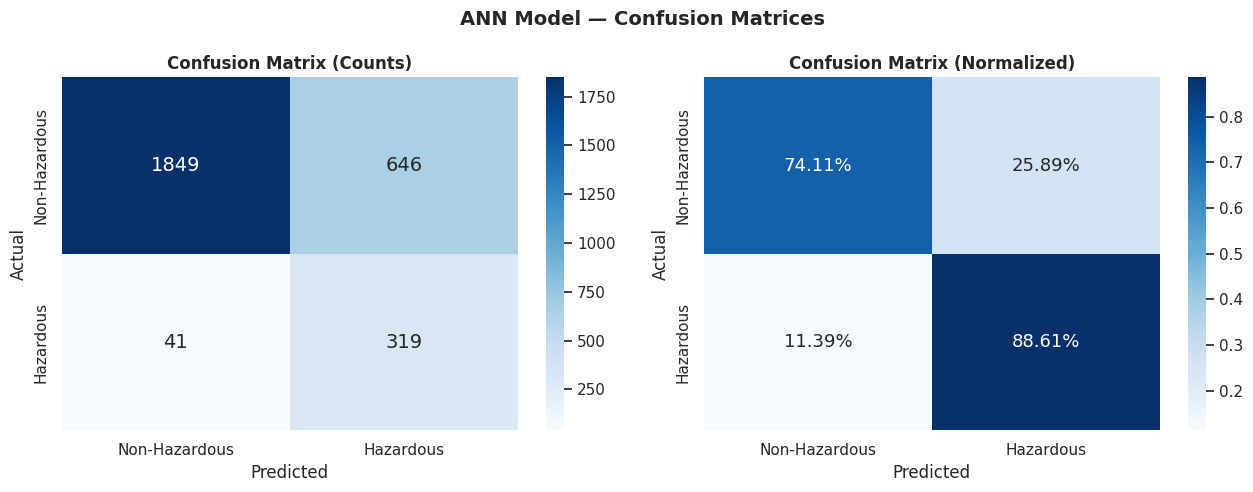

  True Negatives  (Non-Haz correctly identified): 1,849
  False Positives (Non-Haz predicted as Haz)    : 646
  False Negatives (Missed Hazardous!)            : 41  ← minimize this
  True Positives  (Hazardous correctly caught)  : 319


In [66]:
#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Hazardous', 'Hazardous'],
            yticklabels=['Non-Hazardous', 'Hazardous'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Non-Hazardous', 'Hazardous'],
            yticklabels=['Non-Hazardous', 'Hazardous'],
            annot_kws={'size': 13})
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('ANN Model — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  True Negatives  (Non-Haz correctly identified): {tn:,}')
print(f'  False Positives (Non-Haz predicted as Haz)    : {fp:,}')
print(f'  False Negatives (Missed Hazardous!)            : {fn:,}  ← minimize this')
print(f'  True Positives  (Hazardous correctly caught)  : {tp:,}')

# **Step 12: ANN vs Random Forest — Comparison**

In [67]:
rf_metrics = {
    'Model'    : 'Random Forest (Sprint 3)',
    'Accuracy' : 0.8444,
    'Precision': 0.3610,
    'Recall'   : 0.7787,
    'F1 Score' : 0.4933,
    'ROC-AUC'  : 0.9183
}

In [68]:
ann_metrics = {
    'Model'    : 'ANN (this notebook)',
    'Accuracy' : round(acc,  4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec,  4),
    'F1 Score' : round(f1,   4),
    'ROC-AUC'  : round(auc,  4)
}

In [69]:
comparison_df = pd.DataFrame([rf_metrics, ann_metrics]).set_index('Model')

In [70]:
comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest (Sprint 3),0.8444,0.3610,0.7787,0.4933,0.9183
ANN (this notebook),0.7594,0.3306,0.8861,0.4815,0.8722


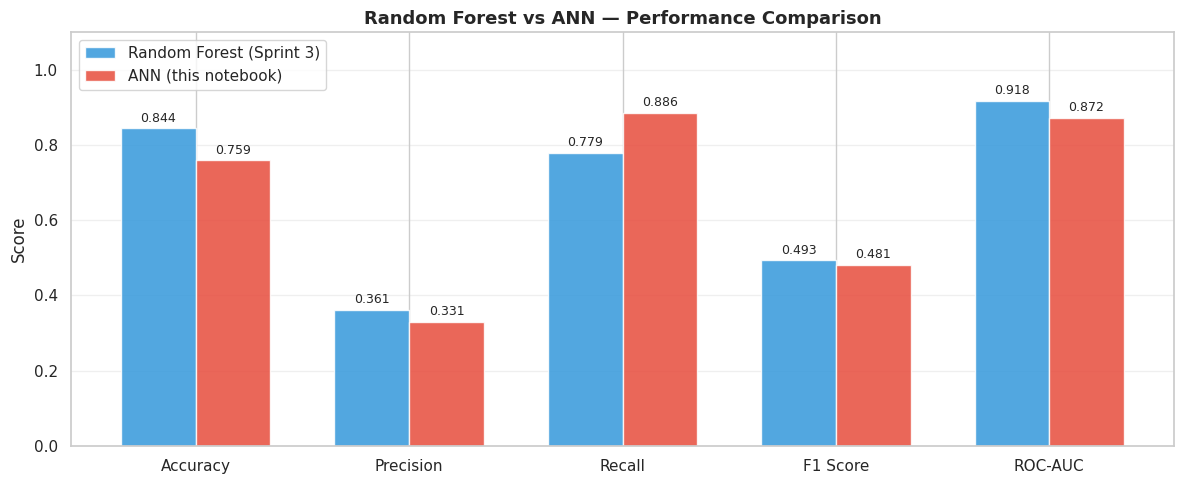

In [71]:
# Visual comparison
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
rf_vals  = [rf_metrics[m]  for m in metric_names]
ann_vals = [ann_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, rf_vals,  width, label='Random Forest (Sprint 3)', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, ann_vals, width, label='ANN (this notebook)',      color='#e74c3c', alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest vs ANN — Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# **Step 13: Save ANN Model & Artifacts**

In [74]:
import joblib, json, datetime

os.makedirs('models_ann', exist_ok=True)

# 1. Save Keras model
final_model.save('models_ann/ann_model.keras')

# 2. Save scaler
joblib.dump(scaler, 'models_ann/scaler_ann.joblib')

# 3. Save feature names
with open('models_ann/feature_names.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

# 4. Save metadata
metadata = {
    'model_name'      : 'ANN (TensorFlow/Keras)',
    'version'         : '1.0.0',
    'trained_on'      : str(datetime.date.today()),
    'n_features'      : X_train_s.shape[1],
    'feature_names'   : X.columns.tolist(),
    'best_threshold'  : round(float(best_threshold), 2),
    'architecture'    : {
        'layers'   : [best_config['units_1'], best_config['units_2'], best_config['units_3']],
        'dropout'  : best_config['dropout_rate'],
        'l2_reg'   : best_config['l2'],
        'optimizer': 'Adam',
        'loss'     : 'binary_crossentropy'
    },
    'metrics': {
        'accuracy' : round(acc,  4),
        'precision': round(prec, 4),
        'recall'   : round(rec,  4),
        'f1_score' : round(f1,   4),
        'roc_auc'  : round(auc,  4)
    }
}

with open('models_ann/ann_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('ANN artifacts saved to models_ann/:')
for fname in os.listdir('models_ann'):
    size = os.path.getsize(f'models_ann/{fname}')
    print(f'   📦 {fname}  ({size:,} bytes)')

ANN artifacts saved to models_ann/:
   📦 scaler_ann.joblib  (1,287 bytes)
   📦 ann_metadata.json  (845 bytes)
   📦 feature_names.json  (198 bytes)
   📦 ann_model.keras  (590,688 bytes)


# **Step 14: Inference Function**

In [75]:
def predict_hazard_ann(input_dict: dict) -> dict:
    """
    Predict asteroid hazard using the trained ANN.

    Parameters
    ----------
    input_dict : dict
        Keys: est_diameter_min, est_diameter_max, relative_velocity,
              miss_distance, absolute_magnitude

    Returns
    -------
    dict — prediction (0/1), probability, risk_label
    """
    # Load saved artifacts
    ann  = keras.models.load_model('models_ann/ann_model.keras')
    sc   = joblib.load('models_ann/scaler_ann.joblib')
    with open('models_ann/ann_metadata.json') as f:
        meta = json.load(f)
    threshold  = meta['best_threshold']
    feat_names = meta['feature_names']

    row = pd.DataFrame([input_dict])

    # Feature engineering (same as training)
    row['Avg_diameter']            = (row['est_diameter_min'] + row['est_diameter_max']) / 2
    row['Diameter_range']          = row['est_diameter_max'] - row['est_diameter_min']
    row['Velocity_distance_ratio'] = row['relative_velocity'] / row['miss_distance']
    row['log_velocity']            = np.log1p(row['relative_velocity'])
    row['log_miss_distance']       = np.log1p(row['miss_distance'])

    row = row[feat_names]   # ensure column order matches training

    row_scaled = sc.transform(row)
    prob = float(ann.predict(row_scaled, verbose=0)[0][0])
    pred = int(prob >= threshold)

    return {
        'prediction' : pred,
        'probability': round(prob, 4),
        'risk_label' : ' HAZARDOUS' if pred == 1 else ' NON-HAZARDOUS'
    }

print(' predict_hazard_ann() ready!')

 predict_hazard_ann() ready!


In [80]:
# ── Test with sample asteroids ───────────────────────────────────
test_cases = [
    {
        'label': 'Small/slow/distant → Expected: Safe',
        'data' : {'est_diameter_min':0.25,'est_diameter_max':0.56,
                  'relative_velocity':75000,'miss_distance':35000000,'absolute_magnitude':20.5}
    },
    {
        'label': 'Large/fast/close → Expected: Hazardous',
        'data' : {'est_diameter_min':1.50,'est_diameter_max':3.20,
                  'relative_velocity':145000,'miss_distance':4000000,'absolute_magnitude':15.5}
    }
]

for tc in test_cases:
    result = predict_hazard_ann(tc['data'])
    print(f'\n {tc["label"]}')
    print(f'   Probability : {result["probability"]*100:.1f}%')
    print(f'   Result      : {result["risk_label"]}')


 Small/slow/distant → Expected: Safe
   Probability : 50.3%
   Result      :  HAZARDOUS



 Large/fast/close → Expected: Hazardous
   Probability : 33.6%
   Result      :  NON-HAZARDOUS


# **Step 15: Final Summary**

In [81]:
print('=' * 65)
print('          NEO ANN PROJECT — FINAL SUMMARY')
print('=' * 65)
print(f'✔ Framework         : TensorFlow {tf.__version__} / Keras')
print(f'✔ Architecture      : {best_config["units_1"]} → {best_config["units_2"]} → {best_config["units_3"]} → 1')
print(f'✔ Activation        : ReLU (hidden) + Sigmoid (output)')
print(f'✔ Regularization    : Dropout ({best_config["dropout_rate"]}) + L2 ({best_config["l2"]}) + BatchNorm')
print(f'✔ Optimizer         : Adam (lr={best_config["lr"]})')
print(f'✔ Loss              : Binary Cross-Entropy')
print(f'✔ Class Imbalance   : Handled via class_weight={class_weight_dict}')
print(f'✔ Threshold Tuned   : {best_threshold:.2f} (optimized for F1 on val set)')
print(f'✔ Feature Engineered: 5 new features from 5 original')
print(f'✔ Total Input Dim   : {X_train_s.shape[1]} features')
print()
print('📊 FINAL TEST METRICS:')
print(f'   Accuracy  : {acc:.4f}')
print(f'   Precision : {prec:.4f}')
print(f'   Recall    : {rec:.4f}  ← catches {rec*100:.1f}% of all hazardous asteroids')
print(f'   F1 Score  : {f1:.4f}')
print(f'   ROC-AUC   : {auc:.4f}')
print()
print('💾 SAVED ARTIFACTS:')
print('   models_ann/ann_model.keras      ← full Keras model')
print('   models_ann/scaler_ann.joblib    ← StandardScaler')
print('   models_ann/feature_names.json   ← input feature list')
print('   models_ann/ann_metadata.json    ← hyperparams + metrics')
print('=' * 65)

          NEO ANN PROJECT — FINAL SUMMARY
✔ Framework         : TensorFlow 2.20.0 / Keras
✔ Architecture      : 256 → 128 → 64 → 1
✔ Activation        : ReLU (hidden) + Sigmoid (output)
✔ Regularization    : Dropout (0.3) + L2 (0.001) + BatchNorm
✔ Optimizer         : Adam (lr=0.001)
✔ Loss              : Binary Cross-Entropy
✔ Class Imbalance   : Handled via class_weight={0: np.float64(0.5721442885771543), 1: np.float64(3.9652777777777777)}
✔ Threshold Tuned   : 0.47 (optimized for F1 on val set)
✔ Feature Engineered: 5 new features from 5 original
✔ Total Input Dim   : 10 features

📊 FINAL TEST METRICS:
   Accuracy  : 0.7594
   Precision : 0.3306
   Recall    : 0.8861  ← catches 88.6% of all hazardous asteroids
   F1 Score  : 0.4815
   ROC-AUC   : 0.8722

💾 SAVED ARTIFACTS:
   models_ann/ann_model.keras      ← full Keras model
   models_ann/scaler_ann.joblib    ← StandardScaler
   models_ann/feature_names.json   ← input feature list
   models_ann/ann_metadata.json    ← hyperparams + 